In [37]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt
import numpy as np

In [38]:
import os
import sys
current_dir = os.path.dirname(os.path.realpath(__name__))
parent_dir = os.path.dirname(current_dir)
print(parent_dir)
sys.path.append(parent_dir)
from src.data.data_loader import DataLoader
dl = DataLoader()
dl.prepare_df()
prepared_df = dl.prepared_df
dl.train_test_split()

C:\Users\jonah.eisen\dsi\global-stock-index-ml-classification


In [39]:
prepared_df.head()

,Last Close,Close,Last Adj Close,Volume,LowProportion,HighProportion,Delta Close
Date,,,,,,,
2003-01-10,5210.040039,5209.209961,5210.339844,1.477200e+09,0.991511,1.004248,-0.830078
2003-01-13,5209.799805,5233.660156,5209.799805,1.371500e+09,0.995975,1.006883,23.860351
2003-01-14,5209.209961,5171.450195,5209.209961,1.355600e+09,0.996499,1.004696,-37.759766
2003-01-15,5233.729980,5165.339844,5233.660156,1.385200e+09,0.986618,1.000290,-68.390136
2003-01-16,5171.450195,5108.509766,5171.450195,1.534600e+09,0.996568,1.006555,-62.940429


In [40]:
dl.X_train.head()

,Last Adj Close,Volume,LowProportion,HighProportion
Date,,,,
2003-01-10,5210.339844,1.477200e+09,0.991511,1.004248
2003-01-13,5209.799805,1.371500e+09,0.995975,1.006883
2003-01-14,5209.209961,1.355600e+09,0.996499,1.004696
2003-01-15,5233.660156,1.385200e+09,0.986618,1.000290
2003-01-16,5171.450195,1.534600e+09,0.996568,1.006555


In [42]:
dl.y_train.head(10)

Date
2003-01-10     -0.830078
2003-01-13     23.860351
2003-01-14    -37.759766
2003-01-15    -68.390136
2003-01-16    -62.940429
2003-01-17   -149.060059
2003-01-21   -145.529786
2003-01-22    -20.619629
2003-01-23    -82.790039
2003-01-24   -208.700195
Name: Delta Close, dtype: float64

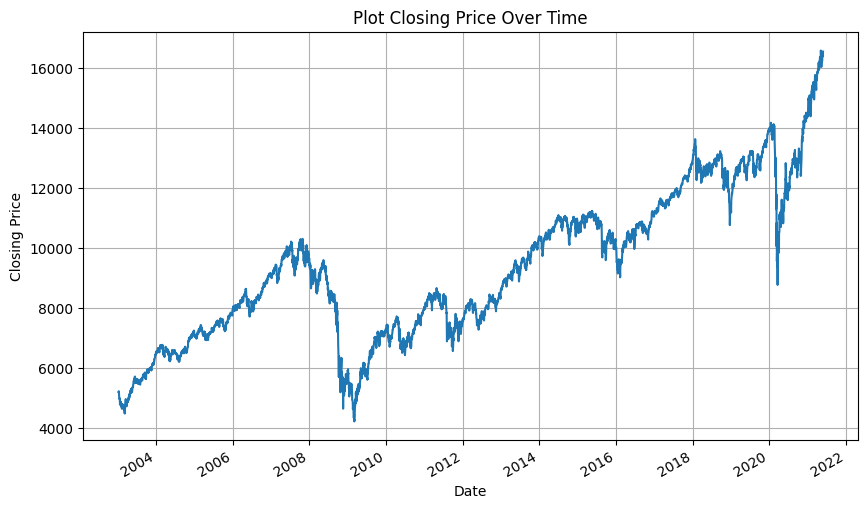

In [35]:
dl.prepared_df['Close'].plot(figsize=(10, 6), title='Plot Closing Price Over Time')

# Add labels and grid
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)

# Display the plot
plt.show()

Closing price doesn't look stationary. Use Augmented Dickey Fuller for quantitative test.

In [10]:
#Augmented Dickey Fuller test fails to reject null hypothesis that closing price time series is non-stationary
#therefore, closing price cannot be treated as stationary. Need to try differencing.
result = adfuller(dl.prepared_df['Close'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -0.4367706225487727
p-value: 0.9037760145897356


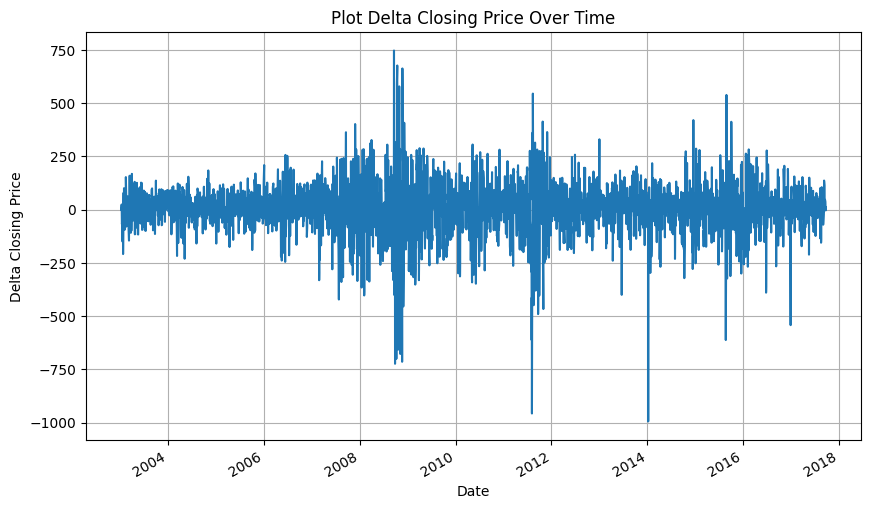

In [43]:
dl.y_train.plot(figsize=(10, 6), title='Plot Delta Closing Price Over Time')

# Add labels and grid
plt.xlabel('Date')
plt.ylabel('Delta Closing Price')
plt.grid(True)

# Display the plot
plt.show()

Delta closing price visually appears to be stationary. Use Augmented Dickey Fuller for quantitative test.

In [45]:
#Augmented Dickey Fuller test rejects null hypothesis that delta closing price time series is non-stationary
#with 1-(p-value) confidence.
#delta closing price can be treated as stationary time
result = adfuller(dl.y_train)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -13.441519244830598
p-value: 3.8369225893250793e-25


In [51]:
rolled = dl.y_train.rolling(window=10).mean().dropna()

rolled_pacf = pacf(rolled, method='ywm')
print(len(rolled_pacf))


36


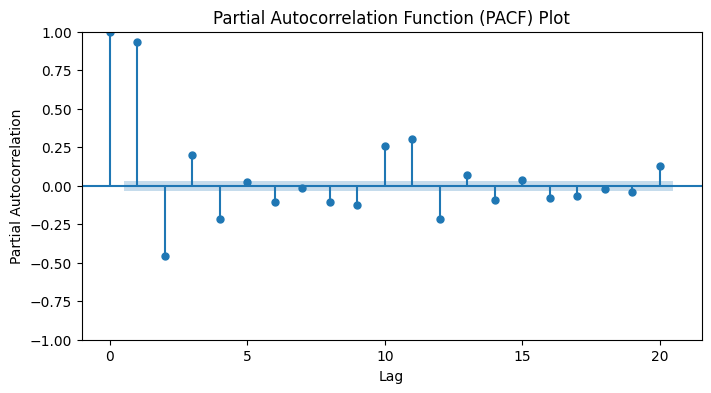

In [52]:
alpha = 0.05
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(rolled, lags=20, alpha=alpha, ax=ax, method='ywm')

# 3. Add title and labels (optional)
ax.set_title('Partial Autocorrelation Function (PACF) Plot')
ax.set_xlabel('Lag')
ax.set_ylabel('Partial Autocorrelation')

# 4. Display the plot
plt.show()

In [53]:
ar_terms = [i for i,val in enumerate(np.abs(rolled_pacf) > alpha) if val]
ar_terms = ar_terms[1:]
ar_terms

[1, 2, 3, 4, 6, 8, 9, 10, 11, 12, 13, 14, 16, 17, 20, 21, 22, 24, 30, 31, 32]

In [54]:
rolled_acf = acf(rolled)
print(len(rolled_acf))

36


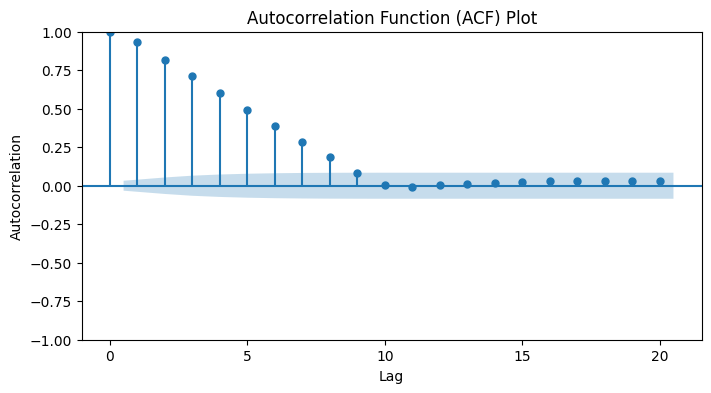

In [55]:
alpha = 0.05
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(rolled, lags=20, alpha=alpha, ax=ax)

# 3. Add title and labels (optional)
ax.set_title('Autocorrelation Function (ACF) Plot')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')

# 4. Display the plot
plt.show()

In [56]:
ma_terms = [i for i,val in enumerate(np.abs(rolled_acf) > alpha) if val]
ma_terms = ma_terms[1:]
ma_terms

[1, 2, 3, 4, 5, 6, 7, 8, 9]